# Jellyfish BEWS — Quickstart

This notebook demonstrates the full pipeline on a single recording bundled with the repo:
`data/example/track.csv` (a 22-minute clean-water recording of one *Aurelia aurita*).

It is **not** a validation notebook — there is only one animal and only clean-water data.
What you can see here is:

1. How `pipeline.py` turns a YOLO `track.csv` into `window_features.csv`
2. How `bews.py` fits a per-animal baseline and scores windows
3. How clean-water `mean|z|` looks: roughly normally distributed around 0.7, never approaching the
   pollution-detection threshold of T_z ≈ 1.56

For the full multi-animal validation, see `notebooks/bews_demo.ipynb`.


In [1]:
# Make src/ importable
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve() / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pipeline      # the feature-extraction pipeline
from bews import AnimalBaseline, BEWSDetector

plt.rcParams.update({'font.size': 9, 'figure.dpi': 110,
                     'axes.spines.top': False, 'axes.spines.right': False})


## 1 · Run the feature-extraction pipeline

`pipeline.run('track.csv')` returns a DataFrame of per-window features.

In [2]:
TRACK_CSV = Path('..') / 'data' / 'example' / 'track.csv'

features = pipeline.run(TRACK_CSV)
print(f'Extracted {len(features)} feature windows from {TRACK_CSV.name}')
features.head()


Extracted 42 feature windows from track.csv


,t_mid,Fp,ipi_cv,amp_rel,spec_ent,speed_mean,speed_cv,tortuosity,v_vert,immobility,conf_mean,dropout,bell_diam_px
0,29.979950,0.696977,0.608635,0.432079,0.504350,36.750515,0.690126,19.313580,0.419265,0.478019,0.904494,0.0,151.563355
1,59.976583,0.611633,0.555924,0.343239,0.507712,38.601994,0.681145,7.906827,-0.255553,0.442404,0.897635,0.0,144.877589
2,89.973217,0.658682,0.538126,0.470638,0.563299,44.027094,0.726732,11.437172,-0.375033,0.396772,0.898622,0.0,150.492982
3,119.969850,0.832501,0.527643,0.470638,0.580562,51.864017,0.668878,67.788332,0.105611,0.293267,0.891545,0.0,151.242491
4,149.966483,0.881471,0.486355,0.368596,0.558911,47.308835,0.658599,78.563424,0.153484,0.323873,0.893064,0.0,146.034929


## 2 · Inspect the bell-area pulsation

Plot a few of the per-window features over the recording. Even within a single clean-water
recording, the animal's pulsation frequency varies by a factor of ~2 (about 0.5 to 1.3 Hz),
illustrating why detection thresholds must be calibrated per-animal.

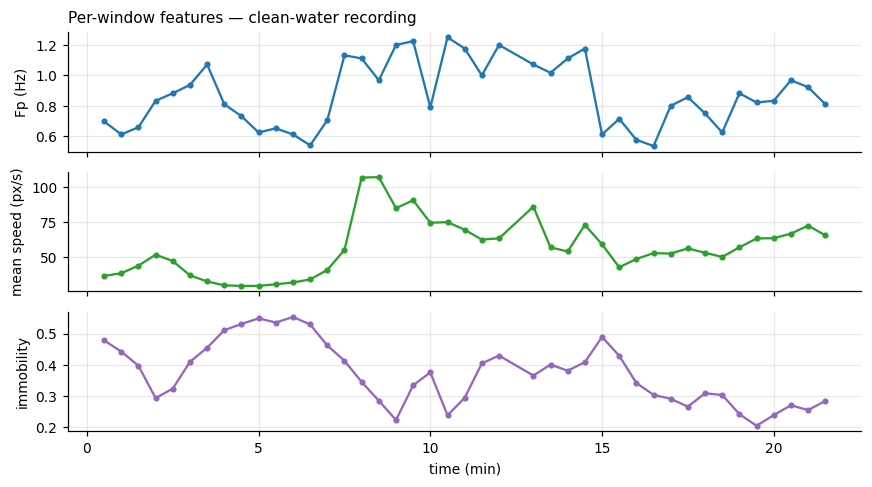

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(8, 4.5), sharex=True)

axes[0].plot(features['t_mid']/60, features['Fp'], '-o', ms=3, color='C0')
axes[0].set_ylabel('Fp (Hz)')
axes[0].set_title('Per-window features — clean-water recording', loc='left', fontsize=10)

axes[1].plot(features['t_mid']/60, features['speed_mean'], '-o', ms=3, color='C2')
axes[1].set_ylabel('mean speed (px/s)')

axes[2].plot(features['t_mid']/60, features['immobility'], '-o', ms=3, color='C4')
axes[2].set_ylabel('immobility')
axes[2].set_xlabel('time (min)')

for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 3 · Fit a per-animal baseline

In a real deployment, the first 15+ minutes of clean water would be used as the calibration set.
Here we use the whole 22-minute recording (it's all clean) and split it into a calibration half
and a "monitoring" half so we can see how `mean|z|` looks on data the baseline has never seen.

In [4]:
half = len(features) // 2
calibration = features.iloc[:half]
monitoring  = features.iloc[half:]

baseline = AnimalBaseline().fit(calibration)
scored = baseline.score(monitoring)
print(f'Calibration: {len(calibration)} windows; monitoring: {len(monitoring)} windows')
print(f"Calibration μ(Fp) = {baseline.mu['Fp']:.3f}, σ(Fp) = {baseline.sd['Fp']:.3f}")
print(f"Monitoring mean|z|: median = {scored['mean_abs_z'].median():.3f}, max = {scored['mean_abs_z'].max():.3f}")


Calibration: 21 windows; monitoring: 21 windows
Calibration μ(Fp) = 0.859, σ(Fp) = 0.228
Monitoring mean|z|: median = 0.800, max = 1.672


## 4 · Apply the detector

We use the deployment-frozen thresholds calibrated on the original 4-animal training set
(reported in `docs/methodology.docx`). Since this is a clean-water recording, no alarm should fire.

In [5]:
DEPLOYMENT_THRESHOLDS = dict(
    threshold_mean_abs_z = 1.559,   # T_z, from training animals
    cusum_target         = 0.715,   # CUSUM reference
    cusum_h              = 5.498,   # CUSUM threshold
    k_consecutive        = 3,
)

detector = BEWSDetector(**DEPLOYMENT_THRESHOLDS)
result = detector.apply(scored)

print(f"Layer 1 alarms (fast): {result['alarm_fast'].sum()} / {len(result)}")
print(f"Layer 2 alarms (CUSUM): {result['alarm_slow'].sum()} / {len(result)}")
print(f"Total alarms: {result['alarm'].sum()} / {len(result)}")
print()
print('All zeros confirm the detector does not raise false alarms on clean-water data.')


Layer 1 alarms (fast): 0 / 21
Layer 2 alarms (CUSUM): 0 / 21
Total alarms: 0 / 21

All zeros confirm the detector does not raise false alarms on clean-water data.


## 5 · Visualise the result

`mean|z|` (Layer 1 score) and CUSUM `S` (Layer 2 score) over the monitoring half. The dotted
lines are the calibrated thresholds. In clean water, both stay well below them.

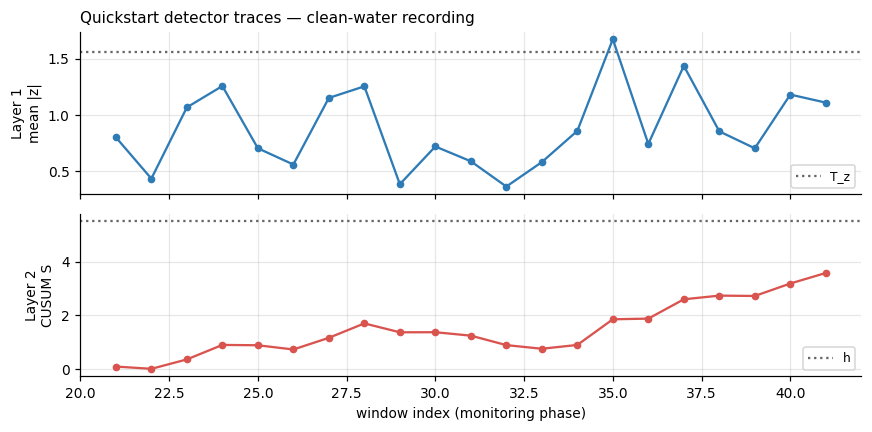

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True)

axes[0].axhline(DEPLOYMENT_THRESHOLDS['threshold_mean_abs_z'],
                ls=':', color='k', alpha=0.6, label='T_z')
axes[0].plot(scored.index, result['mean_abs_z'], '-o', ms=4, color='#2E7BB6')
axes[0].set_ylabel('Layer 1\nmean |z|')
axes[0].set_title('Quickstart detector traces — clean-water recording', loc='left', fontsize=10)
axes[0].legend(fontsize=8)

axes[1].axhline(DEPLOYMENT_THRESHOLDS['cusum_h'],
                ls=':', color='k', alpha=0.6, label='h')
axes[1].plot(scored.index, result['cusum_S'], '-o', ms=4, color='#D9534F')
axes[1].set_ylabel('Layer 2\nCUSUM S')
axes[1].set_xlabel('window index (monitoring phase)')
axes[1].legend(fontsize=8)

for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Next steps

- For the multi-animal validation walkthrough, open `notebooks/bews_demo.ipynb`. It expects
  a folder of `window_features_*.csv` files plus the experimental database `.xlsx` and a
  filled-in `EXPERIMENTS` dictionary.
- For the deployment-time pattern, see the *Minimal deployment example* in the main `README.md`.
- For the methodology and validation results, see `docs/methodology.docx`.
